# scVelo RNA velocity - IL1R1 (2025-2026)

Match the subset loom to the IL1R1 Treg/Th17 AnnData, run scVelo (velocity, velocity graph, pseudotime, PAGA), rank velocity genes and plot a pseudotime-ordered gene heatmap.

_Requires: `scvelo`, `pandas`._

## Setup

In [1]:
import scvelo as scv
import numpy as np
from collections import defaultdict

In [2]:
scv.settings.verbosity = 3  # show errors(0), warnings(1), info(2), hints(3)
scv.settings.presenter_view = True  # set max width size for presenter view
scv.set_figure_params('scvelo')  # for beautified visualization

## Load the merged loom

In [3]:
ldata = scv.read("selected.loom")

In [4]:
loom_cells = np.array(ldata.obs.index)

In [5]:
loom_samples = defaultdict(list)
for x in loom_cells:
    before, sep, after = x.partition(':')
    loom_samples[before + sep].append(after)

## Load IL1R1 data converted from Seurat object and match cells to the loom

In [6]:
import pandas as pd

In [7]:
IL1R1 = scv.read("/home/chanyue/Single_Cell/Priscila_Analysis_2025/Positive_CD3/30PCs/Treg_Th17_04_2026.h5ad")

In [8]:
IL1R1_cells = list(IL1R1.obs.index)
loom_sample_names = list(loom_samples.keys()) 

In [9]:
new_IL1R1_cells = []
for i in range(len(loom_sample_names)):
    for cell in IL1R1_cells:
        before, sep, after = cell.partition('-')
        if after == str(i + 1):
            new_IL1R1_cells.append(loom_sample_names[i] + cell)

### Sanity check: donor mapping matches loom samples

In [10]:
temp = defaultdict(list)
for x in new_IL1R1_cells:
    before, sep, after = x.partition(':')
    temp[before+sep].append(after)

In [11]:
index = [int(x) - 1 for x in np.unique(np.array([x.split("-")[1] for x in IL1R1_cells]))]

In [12]:
set(np.array(loom_sample_names)[index]) == set(temp.keys())

True

## Rename IL1R1 cells and subset the loom

In [13]:
new_IL1R1_cells = [x.split("-")[0] + "x" for x in new_IL1R1_cells]

In [14]:
IL1R1.obs.index = new_IL1R1_cells

In [15]:
ldata = ldata[new_IL1R1_cells, :]

## Run scVelo: velocity + graph

In [16]:
IL1R1 = scv.utils.merge(IL1R1, ldata)

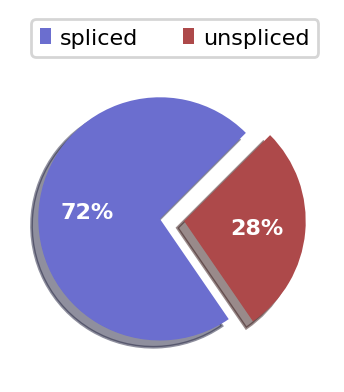

In [17]:
scv.pl.proportions(IL1R1)

In [18]:
scv.pp.filter_and_normalize(IL1R1, min_shared_counts=20, n_top_genes=2000)
scv.pp.moments(IL1R1, n_pcs=30, n_neighbors=30)

Filtered out 16344 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 2000 highly variable genes.
computing neighbors
    finished (0:00:10) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:01) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [19]:
scv.tl.velocity(IL1R1)

computing velocities
    finished (0:00:02) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)


In [ ]:
scv.tl.velocity_graph(IL1R1)

computing velocity graph (using 1/24 cores)


  0%|          | 0/7754 [00:00<?, ?cells/s]

In [ ]:
IL1R1.write_h5ad('./IL1R1_03_2026.h5ad')